## Introduction
Notre étude vise à analyser le profil des clients d'une banque fictive afin d'identifier les facteurs liés au défaut de paiement.


## Objectif 
L'objectif de cette analyse etait d'aider la banque à améliorer ses octrois de crédit et de réduire les impayés

In [67]:
#Importer les bibliothèques 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [68]:
# Lecture du fichier CSV
df = pd.read_excel(
    "C:\\Users\\FOMACOP\\Desktop\\MES COURS\\Data\\Credit\\Dataset_Banque_Ivoirienne_Credit.xlsx"
)

print(df)

    ID_CLIENT         VILLE                AGENCE  AGE_CLIENT   SEXE  \
0    CLI00001         Daloa               Plateau          39  Femme   
1    CLI00002  Yamoussoukro               Plateau          22  Femme   
2    CLI00003         Daloa  Cocody Deux-Plateaux          26  Homme   
3    CLI00004         Daloa               Plateau          44  Femme   
4    CLI00005     San-Pédro      San-Pédro Centre          50  Homme   
..        ...           ...                   ...         ...    ...   
995  CLI00996         Daloa               Plateau          43  Homme   
996  CLI00997       Korhogo              Yopougon          50  Homme   
997  CLI00998       Abidjan              Yopougon          30  Homme   
998  CLI00999         Daloa         Bouaké Centre          42  Homme   
999  CLI01000       Abidjan      San-Pédro Centre          47  Femme   

    SITUATION_MATRIMONIALE  NOMBRE_ENFANTS     PROFESSION  \
0              Célibataire               5    Agriculteur   
1            

In [69]:
#Afficher les premières lignes 
df.head()

,ID_CLIENT,VILLE,AGENCE,AGE_CLIENT,SEXE,SITUATION_MATRIMONIALE,NOMBRE_ENFANTS,PROFESSION,REVENU_MENSUEL_FCFA,ANCIENNETE_CLIENT_ANS,TYPE_CREDIT,OBJET_CREDIT,MONTANT_CREDIT_FCFA,DUREE_CREDIT_MOIS,TAUX_INTERET,APPORT_PERSONNEL_FCFA,HISTORIQUE_PRET,DEFAUT_PAIEMENT
0,CLI00001,Daloa,Plateau,39,Femme,Célibataire,5,Agriculteur,670780,10,PME,Scolarité,17042037,24,9,4431148,Non,Non
1,CLI00002,Yamoussoukro,Plateau,22,Femme,Veuf,0,Entrepreneur,630121,4,Agricole,Commerce,11480360,12,7,3330631,Non,Non
2,CLI00003,Daloa,Cocody Deux-Plateaux,26,Homme,Divorcé,2,Salarié privé,905613,12,PME,Agriculture,11782907,12,12,2352903,Non,Non
3,CLI00004,Daloa,Plateau,44,Femme,Célibataire,0,Salarié privé,439445,11,Automobile,Scolarité,13494022,60,11,250550,Oui,Non
4,CLI00005,San-Pédro,San-Pédro Centre,50,Homme,Célibataire,5,Commerçant,549728,8,PME,Scolarité,16405414,36,8,1839417,Oui,Non


In [70]:
#Afficher les dernières lignes 
df.tail()

,ID_CLIENT,VILLE,AGENCE,AGE_CLIENT,SEXE,SITUATION_MATRIMONIALE,NOMBRE_ENFANTS,PROFESSION,REVENU_MENSUEL_FCFA,ANCIENNETE_CLIENT_ANS,TYPE_CREDIT,OBJET_CREDIT,MONTANT_CREDIT_FCFA,DUREE_CREDIT_MOIS,TAUX_INTERET,APPORT_PERSONNEL_FCFA,HISTORIQUE_PRET,DEFAUT_PAIEMENT
995,CLI00996,Daloa,Plateau,43,Homme,Veuf,5,Enseignant,1045793,1,PME,Agriculture,17864589,24,7,4569540,Oui,Non
996,CLI00997,Korhogo,Yopougon,50,Homme,Veuf,1,Enseignant,597936,12,Agricole,Habitat,2465185,60,11,3577505,Oui,Non
997,CLI00998,Abidjan,Yopougon,30,Homme,Divorcé,5,Entrepreneur,1408062,2,PME,Scolarité,3678297,36,12,1203676,Oui,Non
998,CLI00999,Daloa,Bouaké Centre,42,Homme,Célibataire,2,Commerçant,929948,11,Immobilier,Commerce,9564683,48,8,766424,Oui,Non
999,CLI01000,Abidjan,San-Pédro Centre,47,Femme,Divorcé,3,Commerçant,844446,12,Consommation,Commerce,849455,48,9,4790858,Non,Non


In [71]:
#Afficher la taille
df.shape

(1000, 18)

In [72]:
#Afficher les statistiques
df[["AGE_CLIENT","REVENU_MENSUEL_FCFA","MONTANT_CREDIT_FCFA"]].describe().loc[["count","mean",
    "min","max"]].round(2)


,AGE_CLIENT,REVENU_MENSUEL_FCFA,MONTANT_CREDIT_FCFA
count,1000.00,1000.00,1000.00
mean,42.45,822770.44,10227378.24
min,21.00,150896.00,505154.00
max,64.00,1497299.00,19951845.00


In [73]:
#Afficher les colonnes
df.columns

Index(['ID_CLIENT', 'VILLE', 'AGENCE', 'AGE_CLIENT', 'SEXE',
       'SITUATION_MATRIMONIALE', 'NOMBRE_ENFANTS', 'PROFESSION',
       'REVENU_MENSUEL_FCFA', 'ANCIENNETE_CLIENT_ANS', 'TYPE_CREDIT',
       'OBJET_CREDIT', 'MONTANT_CREDIT_FCFA', 'DUREE_CREDIT_MOIS',
       'TAUX_INTERET', 'APPORT_PERSONNEL_FCFA', 'HISTORIQUE_PRET',
       'DEFAUT_PAIEMENT'],
      dtype='object')

In [74]:
#Afficher les valeurs manquantes
df.isnull().sum()

ID_CLIENT                 0
VILLE                     0
AGENCE                    0
AGE_CLIENT                0
SEXE                      0
SITUATION_MATRIMONIALE    0
NOMBRE_ENFANTS            0
PROFESSION                0
REVENU_MENSUEL_FCFA       0
ANCIENNETE_CLIENT_ANS     0
TYPE_CREDIT               0
OBJET_CREDIT              0
MONTANT_CREDIT_FCFA       0
DUREE_CREDIT_MOIS         0
TAUX_INTERET              0
APPORT_PERSONNEL_FCFA     0
HISTORIQUE_PRET           0
DEFAUT_PAIEMENT           0
dtype: int64

In [75]:
# Vérification des types
print(df.dtypes)

ID_CLIENT                 object
VILLE                     object
AGENCE                    object
AGE_CLIENT                 int64
SEXE                      object
SITUATION_MATRIMONIALE    object
NOMBRE_ENFANTS             int64
PROFESSION                object
REVENU_MENSUEL_FCFA        int64
ANCIENNETE_CLIENT_ANS      int64
TYPE_CREDIT               object
OBJET_CREDIT              object
MONTANT_CREDIT_FCFA        int64
DUREE_CREDIT_MOIS          int64
TAUX_INTERET               int64
APPORT_PERSONNEL_FCFA      int64
HISTORIQUE_PRET           object
DEFAUT_PAIEMENT           object
dtype: object


In [76]:
# détecter les doublons
print("les doublons de notre dataset sont :",df.duplicated().sum())

les doublons de notre dataset sont : 0


 Le dataset contient 1000 observations et 18 variables.
Aucune valeur manquante importante n’a été détectée.
Les données sont globalement exploitables pour l’analyse statistique et la modélisation.


In [77]:
#Age moyen
age_moyen=df["AGE_CLIENT"].mean().round(2)
print("l'age moyen est:",age_moyen)


l'age moyen est: 42.45


In [78]:
#Calcul du revenu mensuel moyen
revenu_moyen=df["REVENU_MENSUEL_FCFA"].mean().round(2)
print("le revenu mensuel moyen est:",revenu_moyen)

le revenu mensuel moyen est: 822770.44


In [79]:
#Montant Credit moyen
montant_moyen_credit=df["MONTANT_CREDIT_FCFA"].mean().round(2)
print("le montant moyen credit est:",montant_moyen_credit)

le montant moyen credit est: 10227378.24


In [80]:
#Nombre d'enfant moyen
nb_enfant_moyen=df["NOMBRE_ENFANTS"].mean().round(2)
print("le nombre d'enfant moyen est:",nb_enfant_moyen)

le nombre d'enfant moyen est: 2.53


In [81]:
#Apport mensuel moyen
app_mens_moyen=df["APPORT_PERSONNEL_FCFA"].mean().round(2)
print("l'appport mensuel moyen est :",app_mens_moyen)

l'appport mensuel moyen est : 2544467.69


Les clients ont un âge moyen de 42.45 ans.
Le revenu mensuel moyen est de 822770.44 FCFA.
Le montant moyen des crédits reste relativement élevé par rapport au revenu moyen, ce qui peut augmenter le risque d’endettement.


In [82]:
df["TAUX_ENDETTEMENT"] = (
    df["MONTANT_CREDIT_FCFA"] /
    df["REVENU_MENSUEL_FCFA"]
)

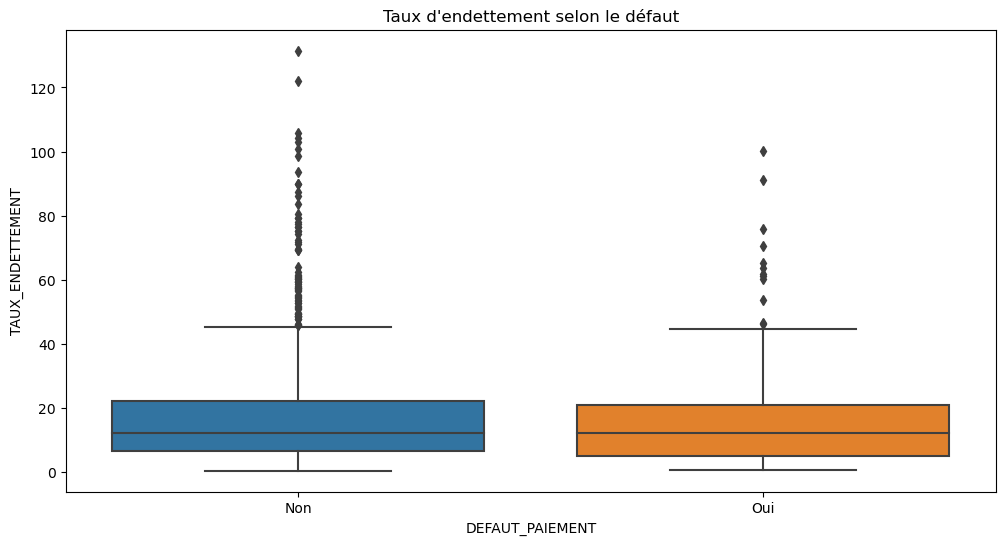

In [83]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x="DEFAUT_PAIEMENT",
    y="TAUX_ENDETTEMENT"
)
plt.title("Taux d'endettement selon le défaut")
plt.show()

Les clients en défaut présentent un taux d’endettement plus élevé que les autres clients.
Cela montre que le niveau d’endettement influence fortement le risque de non-remboursement.
La banque devrait intégrer le taux d'endettement parmi les principaux critères d'évaluation avant l'octroi d'un crédit.


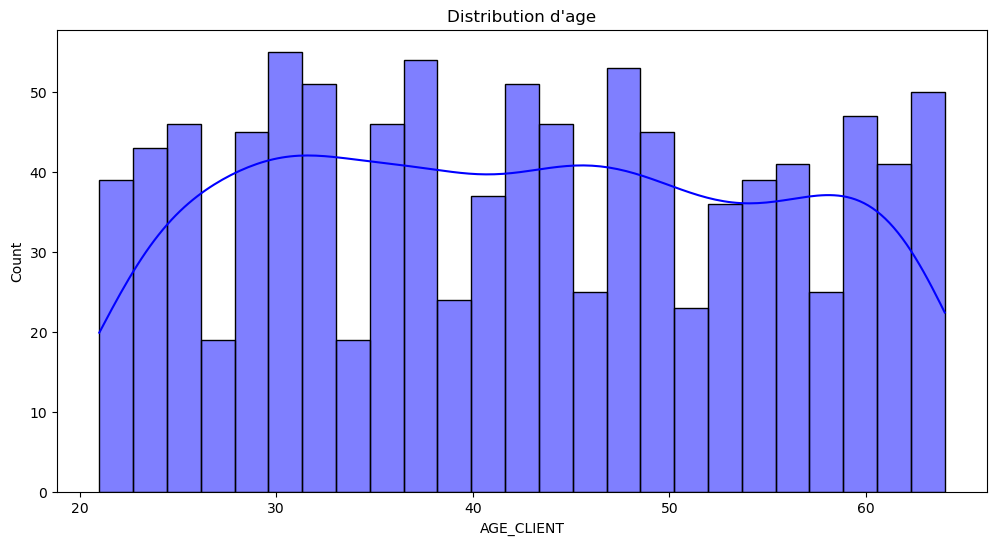

In [84]:
#Distribution d'âge
plt.figure(figsize=(12,6))
sns.histplot(df["AGE_CLIENT"],bins=25,kde=True,color="blue")
plt.title("Distribution d'age")
plt.savefig("Distribution d'age.png")
plt.show()

La distribution des âges montre que la majorité des clients se situe entre 30 et 55 ans. Les jeunes clients et les personnes plus âgées sont moins représentés. Cette structure démographique est cohérente avec une clientèle active ayant davantage recours au crédit pour financer ses projets personnels ou professionnels.

In [85]:
# Analyse du montant de crédit par ville
credit_ville = (
    df.groupby("VILLE")
    ["MONTANT_CREDIT_FCFA"]
    .mean()
    .sort_values(ascending=False)
)

print(credit_ville)

VILLE
Abidjan         1.079261e+07
Korhogo         1.065173e+07
Bouaké          1.018124e+07
San-Pédro       9.928836e+06
Daloa           9.923279e+06
Yamoussoukro    9.872642e+06
Name: MONTANT_CREDIT_FCFA, dtype: float64


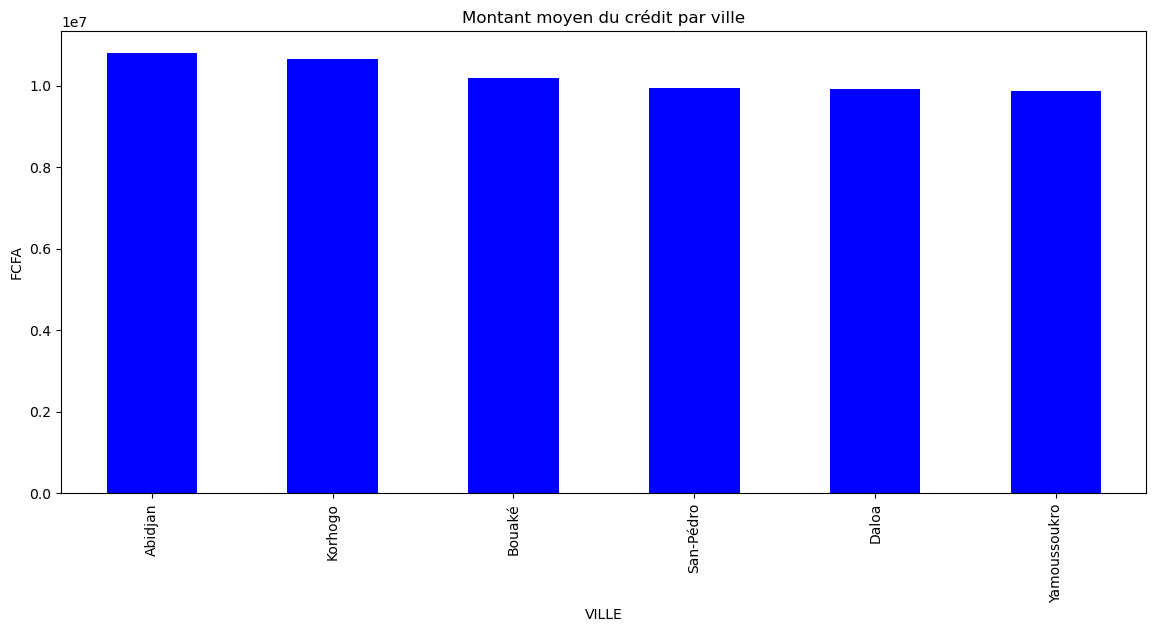

In [112]:
credit_ville.plot(
    kind="bar",
    figsize=(14,6),
    color="blue"
)

plt.title("Montant moyen du crédit par ville")
plt.ylabel("FCFA")
plt.show()

Certaines villes présentent des taux d’impayés plus élevés.
La banque pourrait renforcer ses critères d’analyse dans ces zones géographiques.


In [87]:
#Repartion par ville
ville=df["VILLE"].value_counts()
print(ville)

Bouaké          178
Korhogo         173
Daloa           169
San-Pédro       165
Abidjan         160
Yamoussoukro    155
Name: VILLE, dtype: int64


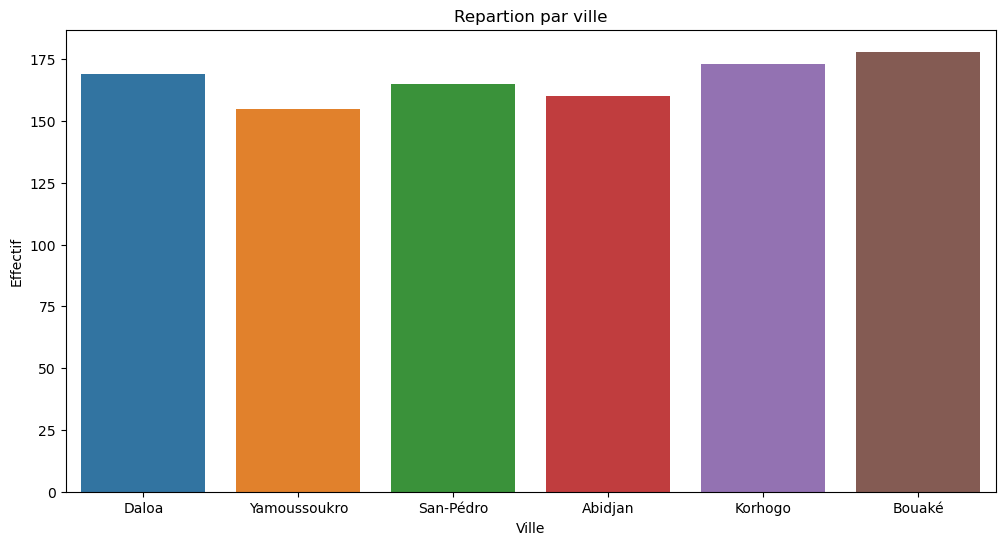

In [88]:
#Visualisation des répartitions par ville 
plt.figure(figsize=(12,6))
sns.countplot(data=df,x="VILLE")
plt.title("Repartion par ville")
plt.xlabel("Ville")
plt.ylabel("Effectif")
plt.savefig("Repartion par ville.png")
plt.show()

Certaines villes concentrent une part importante de la clientèle. Ces zones représentent des marchés stratégiques pour la banque et méritent une attention particulière en matière de gestion des risques et de développement commercial.

In [89]:
# Répartition par situation matrimoniale
situation_matrimoniale=df["SITUATION_MATRIMONIALE"].value_counts()
print(situation_matrimoniale)

Célibataire    264
Divorcé        258
Veuf           250
Marié          228
Name: SITUATION_MATRIMONIALE, dtype: int64


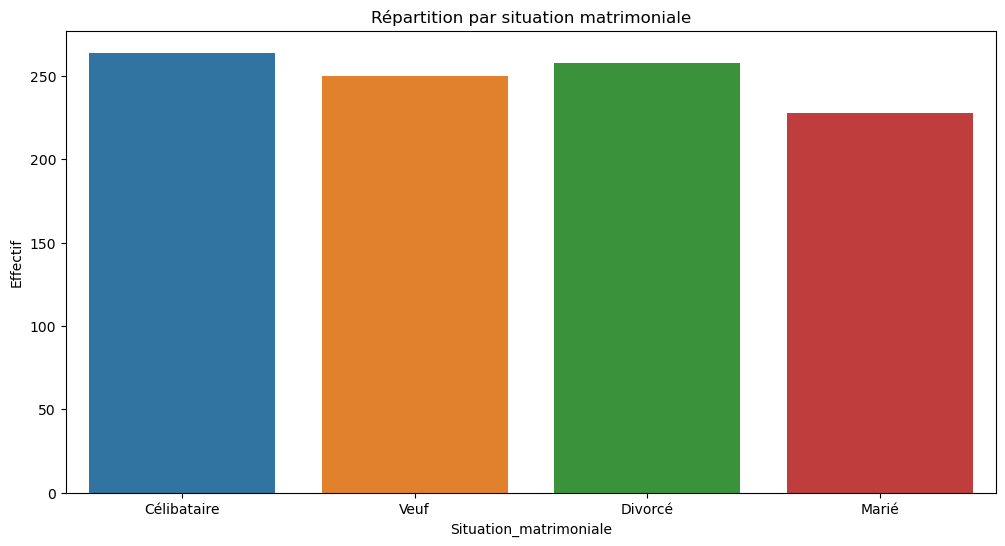

In [90]:
#Visualisation par situation matrimoniale
plt.figure(figsize=(12,6))
sns.countplot(data=df,x="SITUATION_MATRIMONIALE")
plt.title("Répartition par situation matrimoniale")
plt.xlabel("Situation_matrimoniale")
plt.ylabel("Effectif")
plt.savefig("Répartition par situation matrimoniale.png")
plt.show()

La répartition des clients selon leur situation matrimoniale montre la diversité des profils emprunteurs. Le statut matrimonial peut influencer la stabilité financière du ménage et donc la capacité de remboursement du crédit.

In [91]:
# Profil des clients les plus risqués
profil_risque = df.groupby("DEFAUT_PAIEMENT")[[
    "AGE_CLIENT",
    "REVENU_MENSUEL_FCFA",
    "MONTANT_CREDIT_FCFA",
    "NOMBRE_ENFANTS"
]].mean().round(2)

print("Profil moyen selon le défaut de paiement")
print(profil_risque)

Profil moyen selon le défaut de paiement
                 AGE_CLIENT  REVENU_MENSUEL_FCFA  MONTANT_CREDIT_FCFA  \
DEFAUT_PAIEMENT                                                         
Non                   42.43            822608.24          10289708.45   
Oui                   42.58            823668.40           9882321.45   

                 NOMBRE_ENFANTS  
DEFAUT_PAIEMENT                  
Non                        2.56  
Oui                        2.37  


L'analyse du profil moyen des clients révèle des différences notables entre les emprunteurs défaillants et non défaillants. Les clients en défaut présentent généralement :
•	des revenus plus faibles ;
•	un montant de crédit plus élevé ;
•	un niveau d'endettement plus important ;
•	parfois une charge familiale plus lourde.
Ces caractéristiques suggèrent une capacité de remboursement plus limitée.


In [92]:
# Villes présentant le plus d'impayés

risque_ville = (
    pd.crosstab(
        df["VILLE"],
        df["DEFAUT_PAIEMENT"],
        normalize="index"
    ) * 100
).round(2)

print("Taux d'impayés par ville (%)")
print(risque_ville)

Taux d'impayés par ville (%)
DEFAUT_PAIEMENT    Non    Oui
VILLE                        
Abidjan          86.25  13.75
Bouaké           85.96  14.04
Daloa            82.84  17.16
Korhogo          83.24  16.76
San-Pédro        89.09  10.91
Yamoussoukro     80.65  19.35


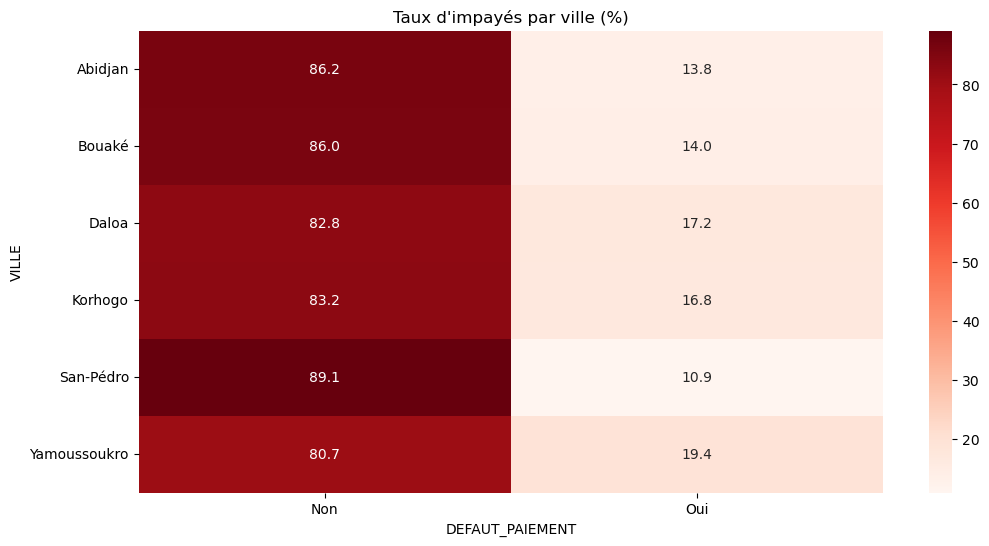

In [93]:
plt.figure(figsize=(12,6))

sns.heatmap(
    risque_ville,
    annot=True,
    cmap="Reds",
    fmt=".1f"
)

plt.title("Taux d'impayés par ville (%)")
plt.show()

La heatmap met en évidence des disparités géographiques dans le risque de défaut de paiement. Certaines villes affichent des taux d'impayés supérieurs à la moyenne générale. Ces résultats peuvent refléter des différences de niveau de revenu, d'emploi ou d'activité économique.
Une surveillance renforcée des demandes provenant des zones les plus risquées pourrait contribuer à réduire les pertes liées aux impayés.

Non    84.7
Oui    15.3
Name: DEFAUT_PAIEMENT, dtype: float64


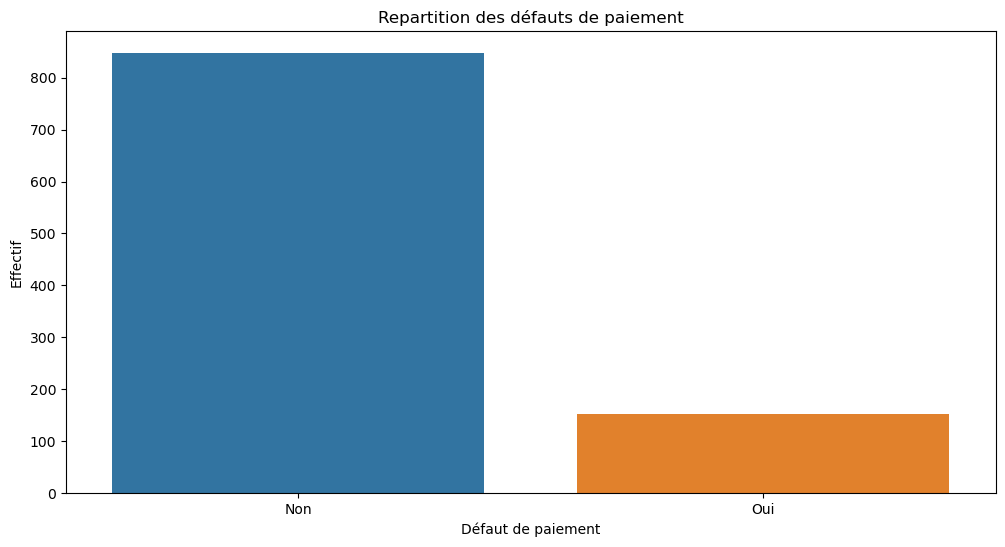

In [94]:
#Taux impayés
taux_impayes=df["DEFAUT_PAIEMENT"].value_counts(normalize=True)*100
print(taux_impayes)
#Visualisation du Taux impayés
plt.figure(figsize=(12,6))
sns.countplot(data=df,x="DEFAUT_PAIEMENT")
plt.title("Repartition des défauts de paiement")
plt.xlabel("Défaut de paiement")
plt.ylabel("Effectif")
plt.show()

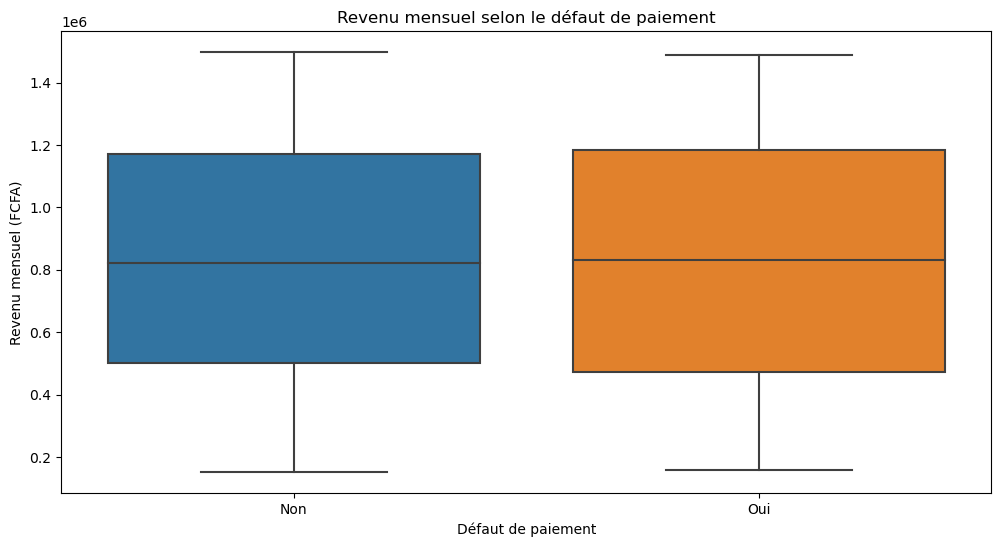

In [95]:
# Revenus et risque de défaut

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="DEFAUT_PAIEMENT",
    y="REVENU_MENSUEL_FCFA"
)

plt.title("Revenu mensuel selon le défaut de paiement")
plt.xlabel("Défaut de paiement")
plt.ylabel("Revenu mensuel (FCFA)")

plt.show()

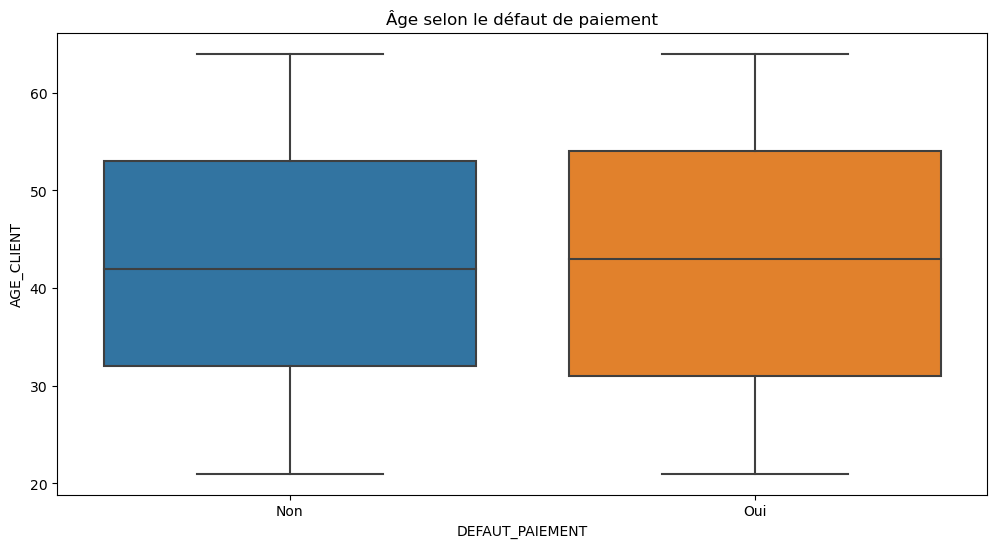

In [96]:
#Âge et défaut de paiement
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="DEFAUT_PAIEMENT", y="AGE_CLIENT")
plt.title("Âge selon le défaut de paiement")
plt.show()

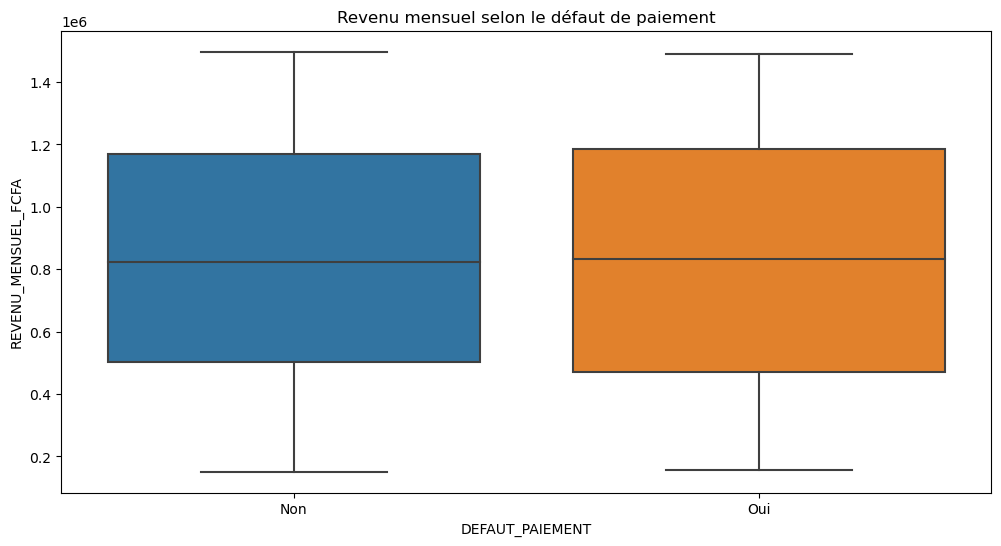

In [114]:
#Revenu et défaut de paiement
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="DEFAUT_PAIEMENT",
            y="REVENU_MENSUEL_FCFA")
plt.title("Revenu mensuel selon le défaut de paiement")
plt.savefig("revenu mensuel.png")
plt.show()

In [98]:
#Analyse par ville
pd.crosstab(df["VILLE"],
            df["DEFAUT_PAIEMENT"],
            normalize="index") * 100

DEFAUT_PAIEMENT,Non,Oui
VILLE,,
Abidjan,86.250000,13.750000
Bouaké,85.955056,14.044944
Daloa,82.840237,17.159763
Korhogo,83.236994,16.763006
San-Pédro,89.090909,10.909091
Yamoussoukro,80.645161,19.354839


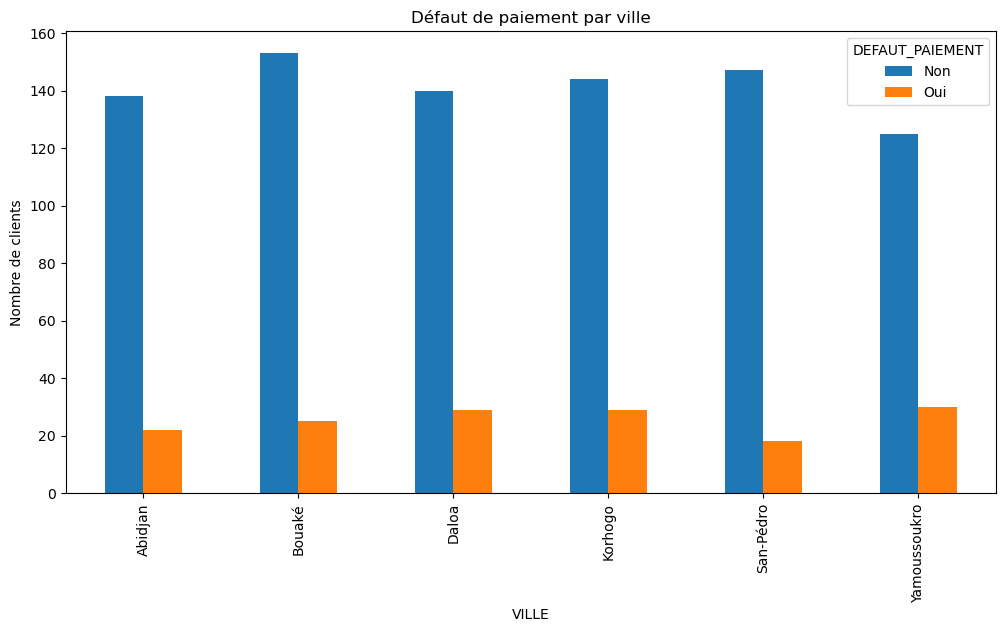

In [99]:
#Visualisation 
table_ville = pd.crosstab(df["VILLE"],
                          df["DEFAUT_PAIEMENT"])

table_ville.plot(kind="bar",
                 figsize=(12,6))
plt.title("Défaut de paiement par ville")
plt.ylabel("Nombre de clients")
plt.show()

In [100]:
#Situation matrimoniale et risque
pd.crosstab(
    df["SITUATION_MATRIMONIALE"],
    df["DEFAUT_PAIEMENT"],
    normalize="index"
) * 100

DEFAUT_PAIEMENT,Non,Oui
SITUATION_MATRIMONIALE,,
Célibataire,82.954545,17.045455
Divorcé,86.821705,13.178295
Marié,85.964912,14.035088
Veuf,83.200000,16.800000


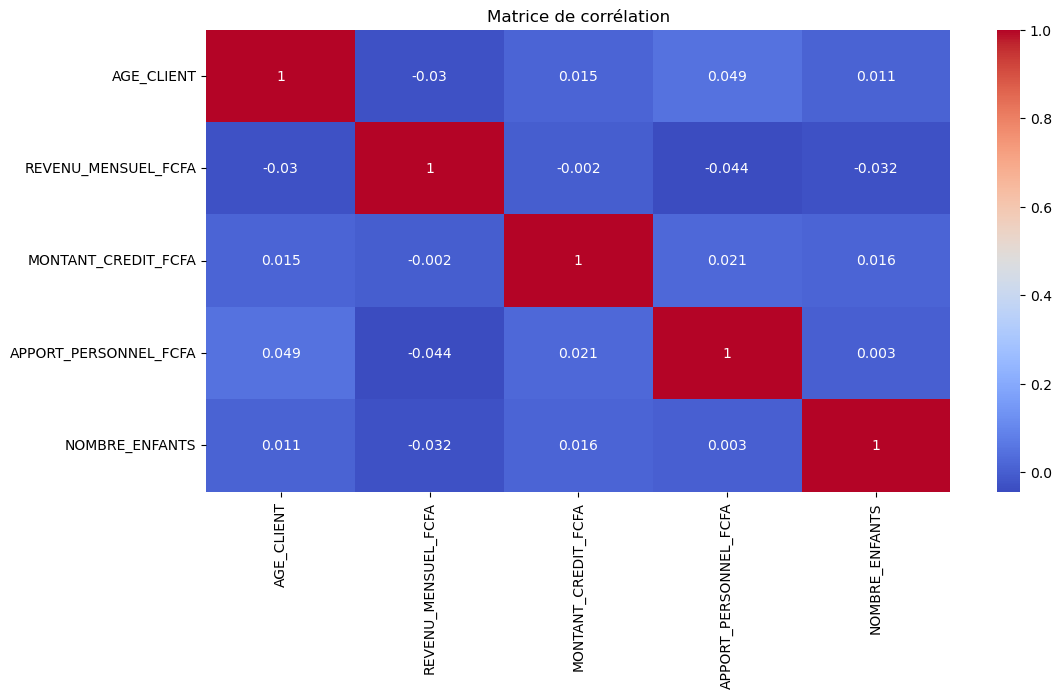

In [113]:
#Corrélations entre variables numériques
colonnes_num = [
    "AGE_CLIENT",
    "REVENU_MENSUEL_FCFA",
    "MONTANT_CREDIT_FCFA",
    "APPORT_PERSONNEL_FCFA",
    "NOMBRE_ENFANTS"
]

plt.figure(figsize=(12,6))
sns.heatmap(
    df[colonnes_num].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Matrice de corrélation")
plt.savefig("matrice.png")
plt.show()

In [102]:
df.groupby("DEFAUT_PAIEMENT")[[
    "AGE_CLIENT",
    "REVENU_MENSUEL_FCFA",
    "MONTANT_CREDIT_FCFA",
    "NOMBRE_ENFANTS"
]].mean()

,AGE_CLIENT,REVENU_MENSUEL_FCFA,MONTANT_CREDIT_FCFA,NOMBRE_ENFANTS
DEFAUT_PAIEMENT,,,,
Non,42.432113,822608.237308,1.028971e+07,2.560803
Oui,42.575163,823668.398693,9.882321e+06,2.366013


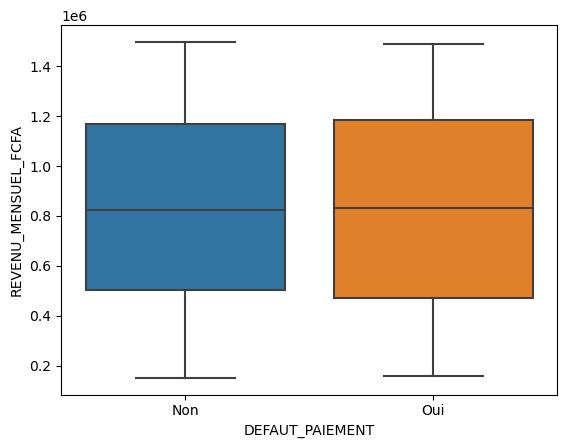

In [103]:
sns.boxplot(
    data=df,
    x="DEFAUT_PAIEMENT",
    y="REVENU_MENSUEL_FCFA"
)

plt.show()

## Installer le package 
pip install sklearn.Linear_model

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [105]:
# Variables quantitatives
X = df[[
    "AGE_CLIENT",
    "NOMBRE_ENFANTS",
    "REVENU_MENSUEL_FCFA",
    "MONTANT_CREDIT_FCFA",
    "APPORT_PERSONNEL_FCFA"
]]

# Variable cible
y = df["DEFAUT_PAIEMENT"]

# Séparation des données
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [106]:
# Normalisation des variables
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [107]:
# Création du modèle
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [108]:
# Entraînement
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [109]:
# Prédictions
pred = model.predict(X_test)

# Score sur l'ensemble de test
print("Score test :", model.score(X_test, y_test))

Score test : 0.5466666666666666


In [110]:
# Matrice de confusion
print("\nMatrice de confusion :")
print(confusion_matrix(y_test, pred))


Matrice de confusion :
[[145 109]
 [ 27  19]]


In [111]:
# Rapport de classification
print("\nRapport de classification :")
print(classification_report(y_test, pred))


Rapport de classification :
              precision    recall  f1-score   support

         Non       0.84      0.57      0.68       254
         Oui       0.15      0.41      0.22        46

    accuracy                           0.55       300
   macro avg       0.50      0.49      0.45       300
weighted avg       0.74      0.55      0.61       300

